In [76]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
# all columns
df = pd.read_csv('../data/ecommerce_sample_clean.csv')

df.tail()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category
499995,2019-10-01 10:22:43,view,26400368,2053013563651392361,unknown,Unknown,194.86,555334137,c74f934a-0713-4a75-a670-1e776c02192d,unknown
499996,2019-10-01 10:22:43,view,23300957,2053013561956893455,unknown,Unknown,36.04,516063919,e8872734-9d35-4c12-92e0-01452dc2635f,unknown
499997,2019-10-01 10:22:43,view,10900328,2053013555069845885,appliances.kitchen.mixer,Dauscher,12.84,529522881,c21547fb-d417-4096-bba1-60582f4732a0,appliances
499998,2019-10-01 10:22:43,view,5701114,2053013553970938175,auto.accessories.player,Prology,25.74,516810731,d7ecd02e-f15f-4f7a-8e43-07e6db9e717d,auto
499999,2019-10-01 10:22:43,view,4100323,2053013561218695907,unknown,Sony,729.47,512788178,65a0f179-7d0a-4bd4-bb41-581e1206e688,unknown


In [79]:
# EXPLORATORY ANALYSIS
# 1. Event type count (how many carts, purchases and views)
df.groupby('event_type').size().reset_index(name='count')

,event_type,count
0,cart,8409
1,purchase,9758
2,view,481833


In [80]:
# 2. user_id unique counts
count = df.groupby('user_id').size().reset_index(name='size')

count[count["size"] == 1]

,user_id,size
5,348609428,1
6,351866718,1
14,374879087,1
18,388419369,1
19,389518481,1
...,...,...
89117,555583810,1
89118,555583843,1
89120,555583879,1
89121,555583927,1


In [81]:
# 3. unique user_session count
count = df.groupby('user_session').size().reset_index(name='size')

count[count["size"] == 1]

,user_session,size
3,000452e3-cfba-4c6f-93e4-5231fb80a248,1
4,0004877e-8ef5-4ffd-90bf-d293b9973991,1
5,00053790-dcfa-4852-bf10-fa526f14f711,1
6,00054715-a7ed-42d6-b891-98cd15d7e70d,1
8,0005957a-094f-4c99-afd1-448bd7d8139a,1
...,...,...
117440,fff77e7c-ab1a-413d-ba03-93f4e3e18927,1
117441,fff78a5f-c6ac-43ea-aaa7-faa71ad2e092,1
117442,fff7b93d-4331-4fcc-b924-5fd49114bd1c,1
117450,fffb1f57-6870-4fd4-b5bf-3f362aa2d152,1


In [82]:
# 4. number of unknown categories and unknown brands
df1 = df.groupby('category_code').size().reset_index(name='count')
df2 = df.groupby('brand').size().reset_index(name='count')

print(df1[df1["category_code"] == 'unknown'])
print()
print(df2[df2["brand"] == 'Unknown'])

    category_code   count
123       unknown  158439

        brand  count
1859  Unknown  71851


In [83]:
# 5. top 10 leading brands
df1 = df.groupby('brand').size().reset_index(name='count')

df1 = df1.loc[df1["brand"] != 'Unknown']

df1.sort_values(by='count', ascending=False).head(10)

,brand,count
1587,Samsung,60975
103,Apple,52349
1977,Xiaomi,34834
860,Huawei,13731
1101,Lucente,8633
275,Bosch,6533
1081,Lg,5199
1692,Sony,4829
8,Acer,4814
1075,Lenovo,4575


In [84]:
# 6. top 10 leading categories
df1 = df.groupby('category').size().reset_index(name='count')

df1 = df1.loc[df1["category"] != 'unknown']

df1.sort_values(by='count', ascending=False).head(10)

,category,count
7,electronics,191696
2,appliances,59624
4,computers,28663
1,apparel,14431
8,furniture,13352
3,auto,12571
5,construction,9548
9,kids,6380
0,accessories,2703
11,sport,2068


In [85]:
# 7. Price stats

# minimum price
min_price = df['price'].min()

# maximum price
max_price = df['price'].max()

# average price
avg_price = df['price'].mean()

# median price
med_price = df['price'].median()

df_price_stats = pd.DataFrame({
    'min_price': [min_price],
    'max_price': [max_price],
    'avg_price': [avg_price],
    'median_price': [med_price]
})

df_price_stats

,min_price,max_price,avg_price,median_price
0,0.0,2574.07,293.302819,157.79


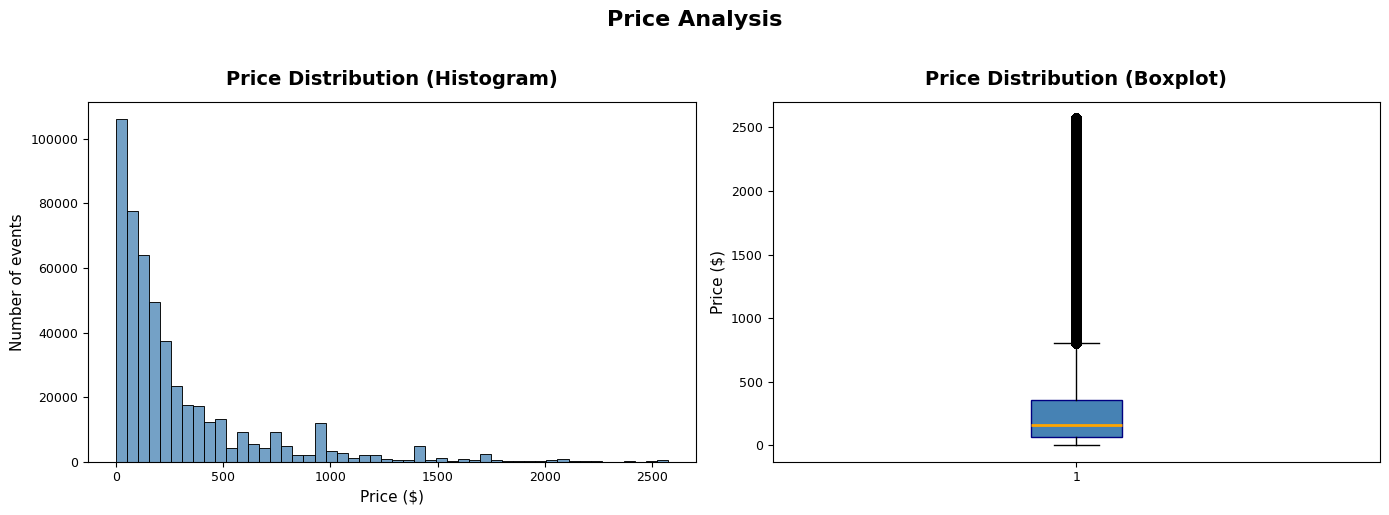

In [86]:
# 8. Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
sns.histplot(
    data=df, 
    x='price',
    bins=50,
    color='steelblue',
    ax=axes[0]
)

axes[0].set_title(
    'Price Distribution (Histogram)',
    fontsize=14,
    fontweight='bold',
    pad=12
)

axes[0].set_xlabel('Price ($)', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].tick_params(labelsize=9)


# boxplot
axes[1].boxplot(
    df['price'], 
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='orange', linewidth=2)
)

axes[1].set_title(
    'Price Distribution (Boxplot)',
    fontsize=14,
    fontweight='bold',
    pad=12
)

axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].tick_params(labelsize=9)

plt.suptitle('Price Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

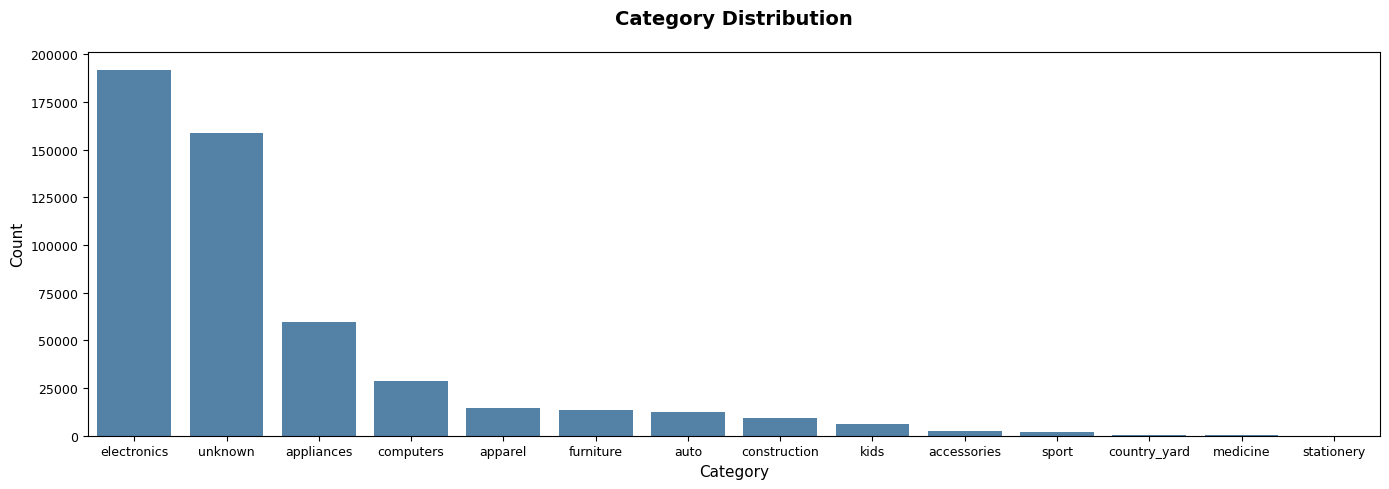

In [87]:
# 9. Category distribution
fig, axes = plt.subplots(figsize=(14, 5))

df_cat = df.groupby('category').size().reset_index(name='count')
df_cat = df_cat.sort_values(by='count', ascending=False)

sns.barplot(
    data=df_cat, 
    x='category', 
    y='count', 
    color='steelblue',
    ax=axes
)

axes.set_title(
    'Category Distribution',
    fontsize=14,
    fontweight='bold',
    pad=20
)

axes.set_xlabel('Category', fontsize=11)
axes.set_ylabel('Count', fontsize=11)
axes.tick_params(labelsize=9)

plt.tight_layout()
plt.show()